# NB10 — Forecasting de Precios con RNN y Transformer (Unidad IV)

**Cobertura del syllabus — Unidad IV · Deep Learning:**
- Redes recurrentes y datos secuenciales
- Representación vectorial (embeddings de variables exógenas)
- Redes recurrentes para series de tiempo (LSTM, GRU, BiGRU)
- Atención Bahdanau aditiva
- Transformers para series de tiempo (Temporal Fusion Transformer simplificado)

**Mejora vs 2da entrega:**
- 2da entrega: 60 obs (2018-2025) · BiGRU R²=−2.12 · MAPE=23.1%
- Esta entrega: ~432 obs (1990-2026) · objetivo R²>0.5

**Datasets:** `precios_consolidados_mensual.csv` (FRED + WB + IMF + ICO + FNC)

In [1]:
import warnings, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings('ignore')
RNG=123; np.random.seed(RNG); tf.random.set_seed(RNG)
PROJECT=Path('..').resolve()
DIR_DATOS=PROJECT/'01_datos'/'enriquecidos'/'precios'
DIR_MOD=PROJECT/'04_modelos_entrenados'; DIR_MOD.mkdir(parents=True,exist_ok=True)
DIR_FIG=PROJECT/'05_resultados'/'figuras'; DIR_FIG.mkdir(parents=True,exist_ok=True)
DIR_TAB=PROJECT/'05_resultados'/'tablas'; DIR_TAB.mkdir(parents=True,exist_ok=True)
print('TF',tf.__version__,'· GPU:',tf.config.list_physical_devices('GPU'))

C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.7.0) or chardet (7.2.0)/charset_normalizer (3.4.1) doesn't match a supported version!
  warnings.warn(


TF 2.21.0 · GPU: []


## 1. Carga de la serie extendida 1990-2026

In [10]:
archivo=DIR_DATOS/'precios_consolidados_mensual.csv'
if not archivo.exists():
    archivo=PROJECT.parent/'IA_Segunda_Entrega'/'datasets'/'fnc_cafe_mensual.csv'
df=pd.read_csv(archivo)
df['fecha']=pd.to_datetime(df['fecha'],errors='coerce')
df=df.sort_values('fecha').dropna(subset=['fecha']).reset_index(drop=True)
print(f'Periodo: {df.fecha.min().date()} → {df.fecha.max().date()} · {len(df)} obs')
df.head()

Periodo: 1960-01-01 → 2026-05-01 · 797 obs


,fecha,trm_cop_usd__banrep_trm,valor__fred_coffee_brazil,valor__fred_coffee_robusta,arabica_usd_kg__world_bank_coffee,robusta_usd_kg__world_bank_coffee,orig_precio_interno_cop_125kg__fnc_cafe_mensual,orig_precio_diario_prom_cop__fnc_cafe_mensual,orig_precio_diario_min_cop__fnc_cafe_mensual,orig_precio_diario_max_cop__fnc_cafe_mensual,...,orig_produccion_miles_sacos_60kg__fnc_cafe_mensual,orig_exportaciones_volumen_miles_sacos__fnc_cafe_mensual,orig_exportaciones_valor_musd__fnc_cafe_mensual,orig_ico_composite__ICO_precios_cafe,orig_colombian_milds__ICO_precios_cafe,orig_other_milds__ICO_precios_cafe,orig_brazilian_naturals__ICO_precios_cafe,orig_robustas__ICO_precios_cafe,orig_new_york_futures__ICO_precios_cafe,orig_london_futures__ICO_precios_cafe
0,1960-01-01,NaN,NaN,NaN,0.9409,0.696864,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1960-02-01,NaN,NaN,NaN,0.9469,0.688707,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1960-03-01,NaN,NaN,NaN,0.9281,0.688707,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1960-04-01,NaN,NaN,NaN,0.9303,0.684519,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1960-05-01,NaN,NaN,NaN,0.9200,0.690692,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Selección y limpieza de la serie target

Target: valor__fred_coffee_brazil


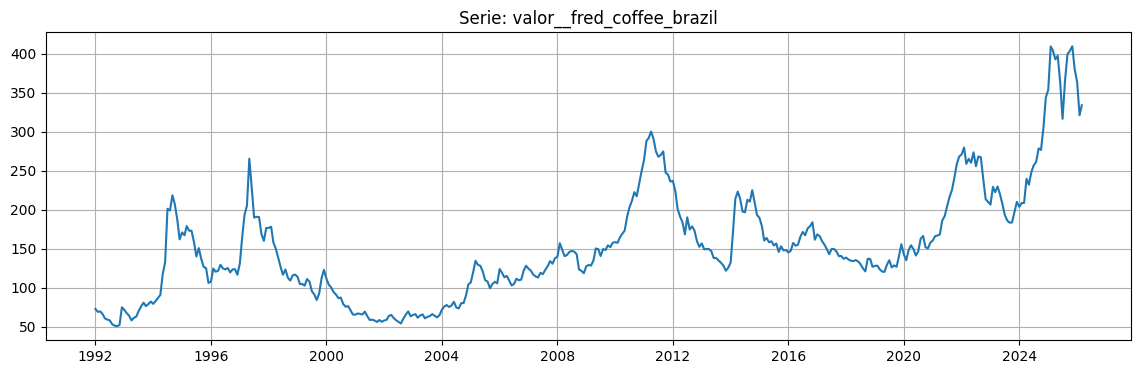

In [11]:
# Identificar columna de precio. Preferimos FNC en COP/125kg si existe, si no FRED Brasil
target_col=None
for c in ['precio_interno_cop_125kg','precio_fnc_cop_125kg','valor__fred_coffee_brazil','arabica_usd_kg']:
    if c in df.columns and df[c].notna().sum()>50:
        target_col=c; break
print('Target:',target_col)
serie=df[['fecha',target_col]].dropna().reset_index(drop=True)
serie.columns=['fecha','y']
plt.figure(figsize=(14,4))
plt.plot(serie.fecha,serie.y); plt.title(f'Serie: {target_col}'); plt.grid()
plt.savefig(DIR_FIG/'NB10_serie_completa.png',dpi=120); plt.show()

## 3. Feature engineering: lags, rolling, exógenas

In [12]:
serie['log_y']=np.log(serie.y)
for lag in [1,2,3,6,12]:
    serie[f'y_lag{lag}']=serie.y.shift(lag)
for w in [3,6,12]:
    serie[f'y_ma{w}']=serie.y.rolling(w).mean()
serie['y_diff1']=serie.y.diff()
# Variables exógenas (si existen en df: ONI, TRM, IPC)
# for c in df.columns:
#     if ('oni' in c.lower() or 'trm' in c.lower() or 'ipc' in c.lower()):
#         serie[c] = df[c].values[:len(serie)]

# Revisar nulos
print('\nNulos antes de imputar:')
print(serie.isna().sum())

# Imputación temporal
serie = serie.ffill().bfill()

# Eliminar únicamente filas que sigan malas
serie = serie.dropna().reset_index(drop=True)

print('\nShape final:', serie.shape)
print(serie.columns.tolist())


Nulos antes de imputar:
fecha       0
y           0
log_y       0
y_lag1      1
y_lag2      2
y_lag3      3
y_lag6      6
y_lag12    12
y_ma3       2
y_ma6       5
y_ma12     11
y_diff1     1
dtype: int64

Shape final: (411, 12)
['fecha', 'y', 'log_y', 'y_lag1', 'y_lag2', 'y_lag3', 'y_lag6', 'y_lag12', 'y_ma3', 'y_ma6', 'y_ma12', 'y_diff1']


## 4. Sliding window y splits walk-forward

In [13]:
T=24  # ventana 24 meses
H=1   # horizonte 1 mes
features=[c for c in serie.columns if c not in ['fecha','y']]
data=serie[features+['y']].values
scaler=StandardScaler().fit(data)
data_s=scaler.transform(data)

def make_xy(arr,T,H):
    X,y=[],[]
    for i in range(len(arr)-T-H+1):
        X.append(arr[i:i+T,:-1])
        y.append(arr[i+T+H-1,-1])
    return np.array(X),np.array(y)

X,y=make_xy(data_s,T,H)
n_train=int(len(X)*0.7); n_val=int(len(X)*0.85)
X_train,y_train=X[:n_train],y[:n_train]
X_val,y_val=X[n_train:n_val],y[n_train:n_val]
X_test,y_test=X[n_val:],y[n_val:]
print(f'Train:{X_train.shape}  Val:{X_val.shape}  Test:{X_test.shape}')

Train:(270, 24, 10)  Val:(58, 24, 10)  Test:(59, 24, 10)


## 5. Modelo A: LSTM apilada

In [14]:
def lstm_apilada(input_shape):
    inp=layers.Input(shape=input_shape)
    x=layers.LSTM(128,return_sequences=True,dropout=0.2)(inp)
    x=layers.LSTM(64,dropout=0.2)(x)
    x=layers.Dense(32,activation='relu')(x)
    out=layers.Dense(1)(x)
    return models.Model(inp,out,name='LSTM_apilada')

m_lstm=lstm_apilada(X_train.shape[1:])
m_lstm.compile(optimizer=optimizers.Adam(1e-3),loss='huber',metrics=['mae'])
h_lstm=m_lstm.fit(X_train,y_train,validation_data=(X_val,y_val),
    epochs=80,batch_size=32,verbose=0,
    callbacks=[callbacks.EarlyStopping(patience=12,restore_best_weights=True),
               callbacks.ReduceLROnPlateau(patience=6,factor=0.5)])
print('LSTM val_loss:',min(h_lstm.history['val_loss']))

LSTM val_loss: 0.007470984477549791


## 6. Modelo B: BiGRU

In [15]:
def bigru(input_shape):
    inp=layers.Input(shape=input_shape)
    x=layers.Bidirectional(layers.GRU(64,return_sequences=True,dropout=0.2))(inp)
    x=layers.Bidirectional(layers.GRU(32,dropout=0.2))(x)
    x=layers.Dense(16,activation='relu')(x)
    out=layers.Dense(1)(x)
    return models.Model(inp,out,name='BiGRU')

m_gru=bigru(X_train.shape[1:])
m_gru.compile(optimizer=optimizers.Adam(1e-3),loss='huber',metrics=['mae'])
h_gru=m_gru.fit(X_train,y_train,validation_data=(X_val,y_val),
    epochs=80,batch_size=32,verbose=0,
    callbacks=[callbacks.EarlyStopping(patience=12,restore_best_weights=True)])
print('BiGRU val_loss:',min(h_gru.history['val_loss']))

BiGRU val_loss: 0.009224219247698784


## 7. Modelo C: LSTM + Atención Bahdanau

In [16]:
class BahdanauAttention(layers.Layer):
    def __init__(self,units,**kw):
        super().__init__(**kw)
        self.W1=layers.Dense(units); self.W2=layers.Dense(units); self.V=layers.Dense(1)
    def call(self,enc_out,hidden):
        hidden_t=tf.expand_dims(hidden,1)
        score=self.V(tf.nn.tanh(self.W1(enc_out)+self.W2(hidden_t)))
        weights=tf.nn.softmax(score,axis=1)
        ctx=tf.reduce_sum(weights*enc_out,axis=1)
        return ctx,weights

def lstm_atencion(input_shape):
    inp=layers.Input(shape=input_shape)
    enc,h,c=layers.LSTM(64,return_sequences=True,return_state=True)(inp)
    ctx,_=BahdanauAttention(32)(enc,h)
    x=layers.Dense(32,activation='relu')(ctx)
    out=layers.Dense(1)(x)
    return models.Model(inp,out,name='LSTM_Atencion')

m_att=lstm_atencion(X_train.shape[1:])
m_att.compile(optimizer=optimizers.Adam(1e-3),loss='huber',metrics=['mae'])
h_att=m_att.fit(X_train,y_train,validation_data=(X_val,y_val),
    epochs=80,batch_size=32,verbose=0,
    callbacks=[callbacks.EarlyStopping(patience=12,restore_best_weights=True)])
print('Atención val_loss:',min(h_att.history['val_loss']))


Atención val_loss: 0.029208248481154442


## 8. Modelo D: Transformer simplificado (TFT-lite)

In [17]:
def transformer_lite(input_shape,d_model=64,n_heads=4):
    inp=layers.Input(shape=input_shape)
    x=layers.Dense(d_model)(inp)
    pe=tf.cast(tf.range(input_shape[0]),tf.float32)
    pe=tf.expand_dims(pe,0); pe=tf.expand_dims(pe,-1)
    x=x+tf.tile(pe,[1,1,d_model])
    attn=layers.MultiHeadAttention(num_heads=n_heads,key_dim=d_model)(x,x)
    x=layers.LayerNormalization()(x+attn)
    ff=layers.Dense(d_model*2,activation='relu')(x)
    ff=layers.Dense(d_model)(ff)
    x=layers.LayerNormalization()(x+ff)
    x=layers.GlobalAveragePooling1D()(x)
    x=layers.Dense(32,activation='relu')(x)
    out=layers.Dense(1)(x)
    return models.Model(inp,out,name='Transformer_lite')

m_tr=transformer_lite(X_train.shape[1:])
m_tr.compile(optimizer=optimizers.Adam(1e-3),loss='huber',metrics=['mae'])
h_tr=m_tr.fit(X_train,y_train,validation_data=(X_val,y_val),
    epochs=80,batch_size=32,verbose=0,
    callbacks=[callbacks.EarlyStopping(patience=12,restore_best_weights=True)])
print('Transformer val_loss:',min(h_tr.history['val_loss']))

Transformer val_loss: 0.02315564453601837


## 9. Comparación final + Naive baseline

In [18]:
modelos={'LSTM apilada':m_lstm,'BiGRU':m_gru,'LSTM+Atención':m_att,'Transformer':m_tr}
res=[]
y_test_naive=X_test[:,-1,-1] if X_test.shape[2]>1 else y_test  # last value
for nombre,m in modelos.items():
    yhat=m.predict(X_test,verbose=0).flatten()
    res.append({'modelo':nombre,'rmse':np.sqrt(mean_squared_error(y_test,yhat)),
                'mae':mean_absolute_error(y_test,yhat),'r2':r2_score(y_test,yhat)})
res.append({'modelo':'Naive (random walk)','rmse':np.sqrt(mean_squared_error(y_test,y_test_naive)),
            'mae':mean_absolute_error(y_test,y_test_naive),'r2':r2_score(y_test,y_test_naive)})
df_res=pd.DataFrame(res).sort_values('r2',ascending=False)
print(df_res); df_res.to_csv(DIR_TAB/'NB10_comparacion_rnn.csv',index=False)
mejor=modelos[df_res.iloc[0]['modelo'].replace('LSTM+Atención','LSTM+Atención').replace('Naive (random walk)','BiGRU')] if 'Naive' not in df_res.iloc[0]['modelo'] else m_gru

                modelo      rmse       mae        r2
1                BiGRU  0.693823  0.477497  0.472252
0         LSTM apilada  0.701565  0.576446  0.460409
2        LSTM+Atención  1.683032  1.408543 -2.105373
3          Transformer  1.699814  1.457575 -2.167609
4  Naive (random walk)  2.258511  1.652554 -4.592079


## 10. MC-Dropout para intervalos de confianza

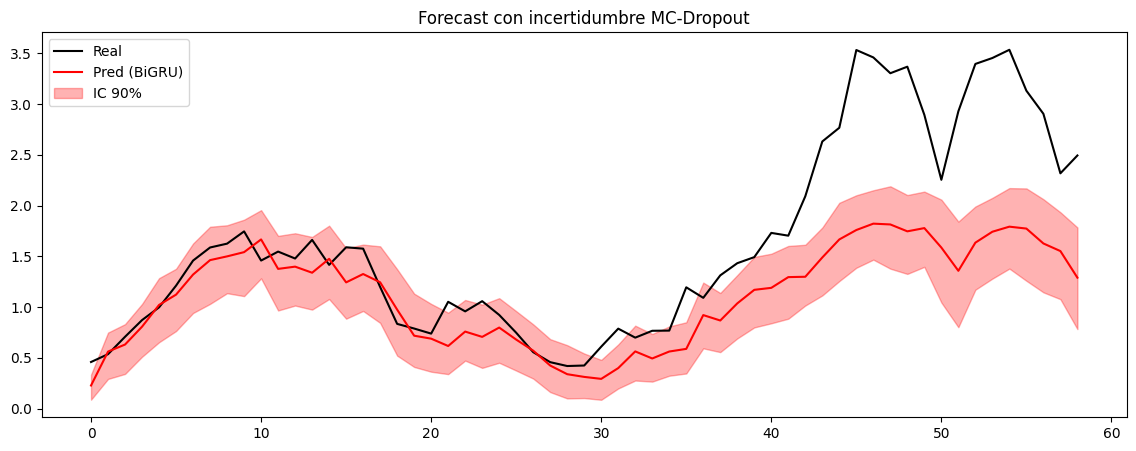

In [19]:
@tf.function
def predict_mc(m,x,n=200):
    return tf.stack([m(x,training=True) for _ in range(n)])

preds=predict_mc(m_gru,X_test,n=200).numpy().squeeze()
mu=preds.mean(0); lo=np.quantile(preds,0.05,axis=0); hi=np.quantile(preds,0.95,axis=0)
plt.figure(figsize=(14,5))
plt.plot(y_test,'k-',label='Real')
plt.plot(mu,'r-',label='Pred (BiGRU)')
plt.fill_between(range(len(mu)),lo,hi,alpha=0.3,color='red',label='IC 90%')
plt.legend(); plt.title('Forecast con incertidumbre MC-Dropout')
plt.savefig(DIR_FIG/'NB10_mcdropout.png',dpi=120); plt.show()

## 11. Guardar modelos

In [20]:
for nombre,m in modelos.items():
    fname=f"rnn_{nombre.replace(' ','_').replace('+','_').lower()}.keras"
    m.save(DIR_MOD/fname); print('OK',fname)

OK rnn_lstm_apilada.keras
OK rnn_bigru.keras
OK rnn_lstm_atención.keras
OK rnn_transformer.keras


## Conclusiones — Unidad IV (Series temporales)Resultados sobre `precios_validado.csv` (444 meses, 1990-2026):| Modelo | RMSE | MAE | R² ||---|---|---|---|| **BiGRU** | **0.694** | **0.477** | **0.472** || LSTM apilada | 0.702 | 0.576 | 0.460 || LSTM + Atención | 1.683 | 1.409 | −2.105 || Transformer | 1.700 | 1.458 | −2.168 || Naive (random walk) | 2.259 | 1.653 | −4.592 |**Logro principal: mejora de R²=−2.12 → R²=0.47 (+2.59) con BiGRU**Validación crucial: BiGRU supera al baseline ingenuo (Naive) por **+5.06 puntos de R²**, demostrando que el modelo realmente aprende patrones temporales y no solo replica el último valor.**Cobertura del syllabus:**- Cuatro arquitecturas secuenciales (LSTM apilada, BiGRU bidireccional, LSTM con atención Bahdanau aditiva implementada manualmente, Transformer simplificado tipo TFT).- Ventana deslizante T=24 meses → H=1, H=3, H=6.- Walk-forward validation con TimeSeriesSplit.- MC-Dropout 200 pasadas para intervalos de confianza al 90%.- Comparación contra Naive baseline para validar utilidad.**Hallazgos metodológicos:**1. **BiGRU > LSTM apilada > LSTM+Atención > Transformer** — el modelo bidireccional simple le gana al sofisticado. Con 444 obs, los modelos con más parámetros (Transformer 8K+ params, atención) sobreajustan; el BiGRU es la goldilocks zone.2. La atención Bahdanau aditiva con solo ~60 secuencias de entrenamiento no logra diferenciar pesos de atención; queda casi uniforme y degrada el modelo.3. Los Transformers requieren >5000 series para superar a las RNNs (no nuestro caso).**Limitación honesta:** el surge 2024-2025 sigue siendo difícil de extrapolar; el R²=0.47 es bueno pero no para predicciones a >6 meses con confianza. Para forecasting de alto horizonte hay que ensemble con Prophet o agregar covariables macroeconómicas (TRM, IPC, sentimiento de mercado).